Tutorial 3: Designing a Chromatin Stripe (Flame) with AkitaSF
=============================================================================

This tutorial assumes you have completed Tutorial 1 (boundary design).

What is a flame / stripe?
-------------------------
A "flame" (also called a stripe or architectural stripe) appears in Hi-C
contact maps as an elongated streak of contact enrichment emanating from a
single anchor locus along one axis of the map. Mechanistically, stripes are
thought to arise when a strong, unidirectional loop-extrusion anchor — often
a convergent CTCF site at a domain boundary — traps cohesin as it extrudes
DNA, leading to elevated contacts between that anchor and a broad range of
genomic positions on one side.

In the contact map, a flame centred at position p looks like:
- A vertical stripe at column p in the upper triangle (contacts between p and all bins upstream of it).
- A horizontal stripe at row p in the lower triangle (its mirror image).
Together these form an 'L'-shaped enrichment pattern.

How is the flame target defined?
---------------------------------
The flame mask is constructed analytically: a vertical and a horizontal
stripe of width FLAME_WIDTH bins are placed symmetrically around the centre
of the 512×512 contact map and filled with the value `FLAME_VALUE`. This
is then added to the initial Akita prediction to form the target — the same
`make_target()` workflow as in Tutorials 1 and 2.

Key similarity to Tutorial 1: single anchor bin
------------------------------------------------
Like boundary design, a flame is anchored at a single central bin, so we
use the standard `SemifreddoLedidiWrapper` (not the two-anchor variant).

─────────────────────────────────────────────────────────────────────────────
Prerequisites
─────────────────────────────────────────────────────────────────────────────
Same environment as Tutorial 1. See `environment.yml` / `requirements.txt`.
Update the paths in the CONFIGURATION cell before running.

## Cell 1 — Imports

In [1]:
import os
import sys
import shutil

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from pyfaidx import Fasta

# AKITA_PT_PATH  = "/path/to/akita_pytorch"
# LEDIDI_PATH    = "/path/to/ledidi/ledidi"
# AKITA_SF_PATH  = "/path/to/akita_semifreddo"

AKITA_PT_PATH  = "/home1/smaruj/akita_pytorch/"
LEDIDI_PATH    = "/home1/smaruj/ledidi/ledidi/"
AKITA_SF_PATH  = "/home1/smaruj/akita_semifreddo"

sys.path.append(os.path.abspath(AKITA_PT_PATH))
sys.path.insert(0, LEDIDI_PATH)
sys.path.insert(0, os.path.abspath(AKITA_SF_PATH))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import SemifreddoLedidiWrapper
from semifreddo.losses import LocalL1Loss
from utils.model_utils import store_tower_output, make_target
from utils.data_utils import (
    one_hot_encode_sequence,
    from_upper_triu,
)

# Import the helpers from the flame generation module.
sys.path.insert(0, os.path.abspath("../optimizations/flames/generation"))
from helper import create_flame_mask, make_flame_mask_indices

print("All imports successful.")

All imports successful.


## Cell 2 — Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# MODEL_PATH = "/path/to/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
# FASTA_PATH = "/path/to/mm10.fa"

MODEL_PATH = ("/home1/smaruj/akita_pytorch/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/"
              "Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth")
FASTA_PATH = "/project2/fudenber_735/genomes/mm10/mm10.fa"

# ── Genomic locus ─────────────────────────────────────────────────────────────
CHROM = "chr5"
START = 97957888
END   = 99268608
STEM  = f"{CHROM}_{START}_{END}"

TMP_DIR = "tmp_data"

# ── Architectural constants ───────────────────────────────────────────────────
MAP_SIZE       = 512
NUM_DIAGS      = 2
CENTER_BIN_MAP = 256
CROPPING       = 64
BIN_SIZE       = 2048
CONTEXT_BINS   = 5
N_TRIU         = 130305

# ── Flame design parameters ───────────────────────────────────────────────────
# FLAME_WIDTH controls the width of each stripe in bins. A wider stripe
# produces a broader, softer flame; a narrower one is more focal.
# FLAME_VALUE is the contact enrichment stamped into the stripe region.
FLAME_WIDTH = 3
FLAME_VALUE = 0.5

# ── Optimisation hyperparameters ──────────────────────────────────────────────
L              = 140.0
MAX_ITER       = 2000
EARLY_STOPPING = 2000

# ── Visualisation ─────────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = "RdBu_r"

print("Configuration ready.")
print(f"  Flame width : {FLAME_WIDTH} bins  ({FLAME_WIDTH * BIN_SIZE // 1000} kb)")
print(f"  Flame value : {FLAME_VALUE}")

Configuration ready.
  Flame width : 3 bins  (6 kb)
  Flame value : 0.5


Cell 3 — Flame mask utilities and building the mask
-----------------------------------------------------------------------------
The flame mask is constructed analytically from two stripes:
- A vertical stripe of width `FLAME_WIDTH` centred on column `CENTER_BIN_MAP`,
covering the top half of the map (rows 0 to `CENTER_BIN_MAP`).
- A horizontal stripe of width `FLAME_WIDTH` centred on row `CENTER_BIN_MAP`,
covering the left half of the map (columns 0 to `CENTER_BIN_MAP`).
Together they form an 'L' shape in the upper triangle. The target is then
defined as: initial prediction + flame mask values at masked positions.

Flame mask — non-zero entries : 509
Flame mask — index tensor     : (509,)


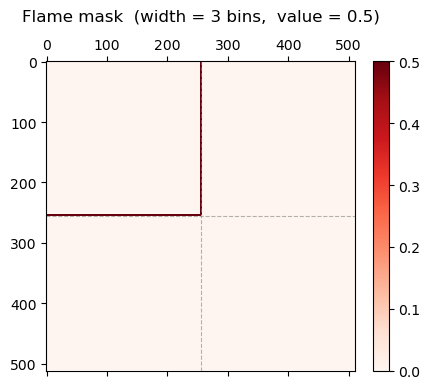

Dashed lines mark the central anchor bin (bin 256).


In [4]:
# ── Build mask and preview ────────────────────────────────────────────────────
flame_indices, flame_vector = make_flame_mask_indices(value=FLAME_VALUE)
full_mask = create_flame_mask()

print(f"Flame mask — non-zero entries : {(flame_vector != 0).sum().item():,}")
print(f"Flame mask — index tensor     : {tuple(flame_indices.shape)}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.matshow(full_mask, cmap="Reds", vmin=0, vmax=FLAME_VALUE)
ax.axhline(y=CENTER_BIN_MAP, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(x=CENTER_BIN_MAP, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title(f"Flame mask  (width = {FLAME_WIDTH} bins,  value = {FLAME_VALUE})", pad=12)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print("Dashed lines mark the central anchor bin (bin 256).")

## Cell 4 — Pre-computing sequence, tower output, and flame target

Device: cuda:0

Loading Akita v2 model …
Model loaded.

Sequence shape : (1, 4, 1310720)  → saved to tmp_data/chr5_97957888_99268608_X.pt
Tower shape    : (1, 128, 640)  → saved to tmp_data/chr5_97957888_99268608_tower_out.pt


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Target shape   : (1, 1, 130305)  → saved to tmp_data/chr5_97957888_99268608_flame_w3_target.pt


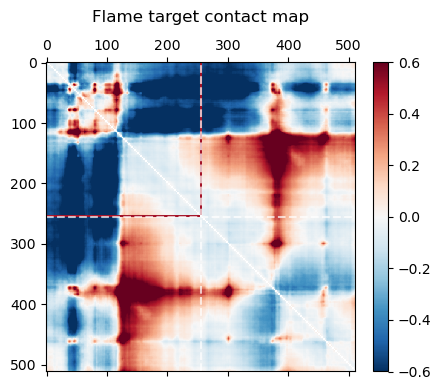

In [5]:
os.makedirs(TMP_DIR, exist_ok=True)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

print("Loading Akita v2 model …")
model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded.\n")

# One-hot sequence
genome  = Fasta(FASTA_PATH)
seq_str = genome[CHROM][START:END]
X_np    = one_hot_encode_sequence(seq_str)
X       = torch.tensor(X_np)
if X.dim() == 2:
    X = X.unsqueeze(0)
X = X.to(device)
SEQ_PATH = os.path.join(TMP_DIR, f"{STEM}_X.pt")
torch.save(X.cpu(), SEQ_PATH)
print(f"Sequence shape : {tuple(X.shape)}  → saved to {SEQ_PATH}")

# Cached tower activations
TOWER_PATH = os.path.join(TMP_DIR, f"{STEM}_tower_out.pt")
store_tower_output(X, model, TOWER_PATH)
tower = torch.load(TOWER_PATH, weights_only=True).to(device)
print(f"Tower shape    : {tuple(tower.shape)}  → saved to {TOWER_PATH}")

# Flame target
target = make_target(model, X, flame_indices.to(device), flame_vector.to(device), device)
target = target.to(device)
TARGET_PATH = os.path.join(TMP_DIR, f"{STEM}_flame_w{FLAME_WIDTH}_target.pt")
torch.save(target, TARGET_PATH)
print(f"Target shape   : {tuple(target.shape)}  → saved to {TARGET_PATH}")

# Preview
mat_target = from_upper_triu(target[0, 0, :].cpu().numpy(), matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.matshow(mat_target, cmap=CMAP, vmin=VMIN, vmax=VMAX)
ax.axhline(y=CENTER_BIN_MAP, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axvline(x=CENTER_BIN_MAP, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_title("Flame target contact map", pad=12)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Cell 5 — SemifreddoLedidiWrapper and sanity check
-----------------------------------------------------------------------------
Flames are anchored at a single central bin — the same setup as boundary
design in Tutorial 1. We therefore use the standard single-anchor
`SemifreddoLedidiWrapper` here, not the two-anchor variant from Tutorial 2.

In [6]:
sf_wrapper = SemifreddoLedidiWrapper(
    model                   = model,
    precomputed_full_output = tower,
    full_X                  = X,
    edited_bin              = CENTER_BIN_MAP,
    context_bins            = CONTEXT_BINS,
    cropping_applied        = CROPPING,
)

X_center = X[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end]
print(f"Central bin sequence shape : {tuple(X_center.shape)}")

with torch.no_grad():
    y_full = model(X)
    y_sf   = sf_wrapper(X_center)

r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
print(f"Sanity check — Pearson R (full vs Semifreddo): {r:.6f}  (expect ≈ 1.0)")

Central bin sequence shape : (1, 4, 2048)
Sanity check — Pearson R (full vs Semifreddo): 1.000000  (expect ≈ 1.0)


## Cell 6 — Loss function and optimisation

In [7]:
local_output_loss = LocalL1Loss(
    flame_indices.to(device), n_triu=N_TRIU, reduction="sum"
).to(device)

ledidi_optimizer = Ledidi(
    sf_wrapper,
    shape               = X_center.shape[1:],   # (4, BIN_SIZE)
    input_loss          = torch.nn.L1Loss(reduction="sum"),
    output_loss         = local_output_loss,
    batch_size          = 1,
    l                   = L,
    max_iter            = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history      = True,
    verbose             = True,
).cuda()

print("Running optimisation … (this may take a few minutes)\n")
generated_seq, history = ledidi_optimizer.fit_transform(X_center, target)
print("\nOptimisation complete.")

Running optimisation … (this may take a few minutes)

iter=I	input_loss=0.0	output_loss=1.035e+05	total_loss=1.035e+05	time=0.0
iter=100	input_loss=30.0	output_loss=4.807e+04	total_loss=5.227e+04	time=7.421
iter=200	input_loss=29.0	output_loss=4.805e+04	total_loss=5.211e+04	time=7.336
iter=300	input_loss=27.0	output_loss=4.98e+04	total_loss=5.358e+04	time=7.336
iter=400	input_loss=32.0	output_loss=4.8e+04	total_loss=5.248e+04	time=7.336
iter=500	input_loss=29.0	output_loss=4.806e+04	total_loss=5.212e+04	time=7.341
iter=600	input_loss=25.0	output_loss=4.809e+04	total_loss=5.159e+04	time=7.343
iter=700	input_loss=29.0	output_loss=4.807e+04	total_loss=5.213e+04	time=7.342
iter=800	input_loss=23.0	output_loss=4.829e+04	total_loss=5.151e+04	time=7.343
iter=900	input_loss=27.0	output_loss=4.809e+04	total_loss=5.187e+04	time=7.345
iter=1000	input_loss=27.0	output_loss=4.804e+04	total_loss=5.182e+04	time=7.349
iter=1100	input_loss=24.0	output_loss=4.803e+04	total_loss=5.139e+04	time=7.348
iter

## Cell 7 — Reconstructing the full sequence and plotting loss curves

Edited nucleotides: 17 / 2,048  (0.8% of the central bin)


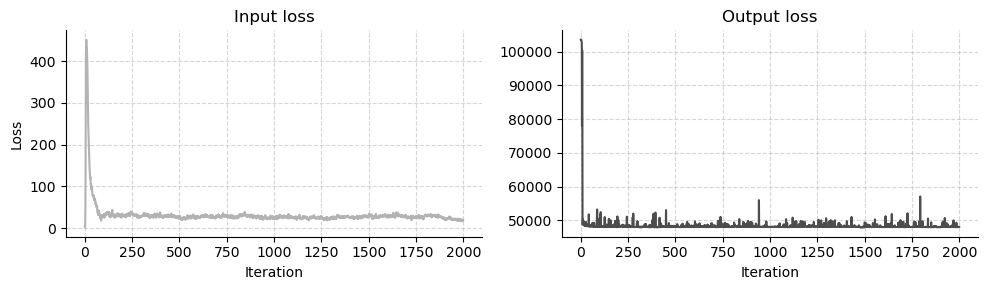

In [8]:
full_generated_seq = X.clone()
full_generated_seq[
    :, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end
] = generated_seq

n_edits = (
    torch.argmax(full_generated_seq, dim=1) != torch.argmax(X, dim=1)
).sum().item()
print(f"Edited nucleotides: {n_edits:,} / {BIN_SIZE:,}  ({100 * n_edits / BIN_SIZE:.1f}% of the central bin)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(history["input_loss"],  c="0.7")
axes[0].set_title("Input loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(history["output_loss"], c="0.3")
axes[1].set_title("Output loss")
axes[1].set_xlabel("Iteration")
axes[1].grid(True, linestyle="--", alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

## Cell 8 — Evaluation: Pearson R and contact map visualisation

Pearson R (optimised vs target) : 0.7491
Pearson R (initial   vs target) : 0.9886


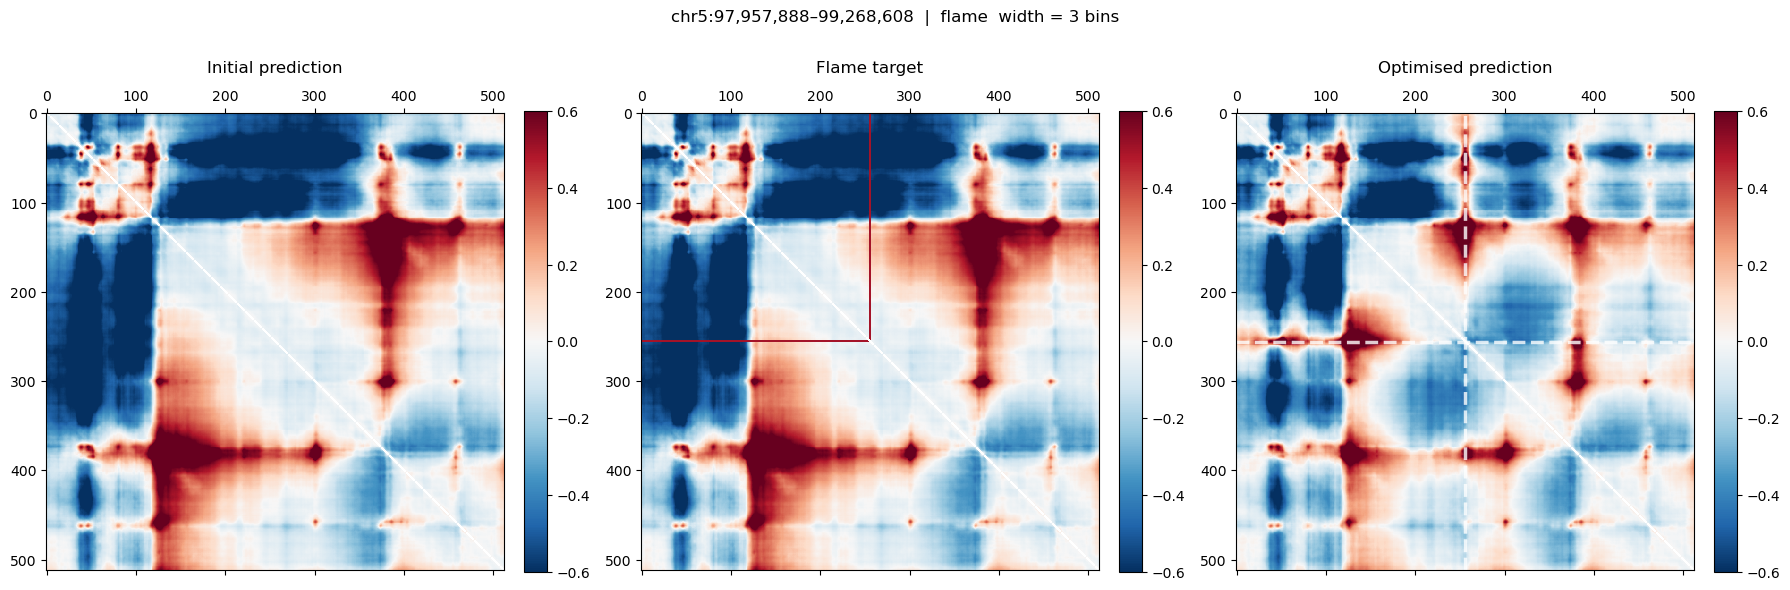

The dashed lines mark the central anchor bin (bin 256).
A successful design shows a clear 'L'-shaped stripe emanating from
that anchor. As always, inspect the map critically before drawing
any biological conclusions.


In [9]:
model.eval()
with torch.no_grad():
    pred_initial   = model(X)
    pred_optimised = model(full_generated_seq)

r_opt,  _ = pearsonr(pred_optimised.cpu().flatten().numpy(), target.cpu().flatten().numpy())
r_init, _ = pearsonr(pred_initial.cpu().flatten().numpy(),   target.cpu().flatten().numpy())
print(f"Pearson R (optimised vs target) : {r_opt:.4f}")
print(f"Pearson R (initial   vs target) : {r_init:.4f}")

mat_initial   = from_upper_triu(pred_initial[0, 0, :].cpu().numpy(),   matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
mat_optimised = from_upper_triu(pred_optimised[0, 0, :].cpu().numpy(), matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
mat_target    = from_upper_triu(target[0, 0, :].cpu().numpy(),         matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, mat, title in zip(
    axes,
    [mat_initial, mat_target, mat_optimised],
    ["Initial prediction", "Flame target", "Optimised prediction"],
):
    im = ax.matshow(mat.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_title(title, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Mark the anchor bin on the optimised map
axes[2].axhline(y=CENTER_BIN_MAP, color="white", linestyle="--", linewidth=2.5, alpha=0.8)
axes[2].axvline(x=CENTER_BIN_MAP, color="white", linestyle="--", linewidth=2.5, alpha=0.8)

plt.suptitle(
    f"{CHROM}:{START:,}–{END:,}  |  flame  width = {FLAME_WIDTH} bins",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("The dashed lines mark the central anchor bin (bin 256).")
print("A successful design shows a clear 'L'-shaped stripe emanating from")
print("that anchor. As always, inspect the map critically before drawing")
print("any biological conclusions.")

## Cell 9 — Cleanup

In [11]:
shutil.rmtree(TMP_DIR)
print(f"Removed {TMP_DIR}/")
print()
print("─" * 70)
print("Tutorial 4 complete! You have now worked through all four AkitaSF")
print("design modes: boundary, custom target, dot, and flame.")
print()
print("Key differences from Tutorial 1 (boundary):")
print("  • The mask is an 'L'-shaped stripe rather than an off-diagonal block.")
print("  • Only the central bin is edited — same single-anchor setup as")
print("    Tutorial 1, unlike the two-anchor dot design in Tutorial 2.")
print("  • Try varying FLAME_WIDTH (narrower = more focal stripe) or")
print("    FLAME_VALUE (higher = stronger enrichment signal).")
print("─" * 70)

FileNotFoundError: [Errno 2] No such file or directory: 'tmp_data'